In [1]:
# https://www.kaggle.com/datasets/nalisha/job-salary-prediction-dataset

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('jobsalary.csv')

In [4]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [6]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


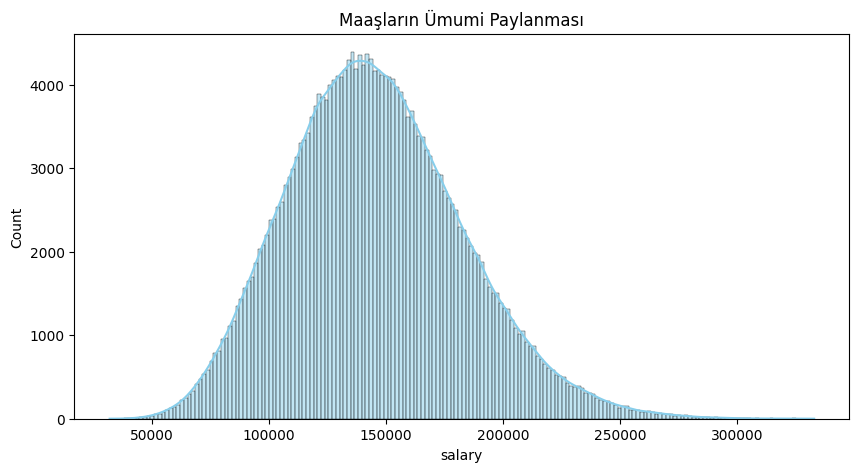

In [7]:
plt.figure(figsize=(10, 5))
sns.histplot(df['salary'], kde=True, color='skyblue')
plt.title('Maaşların Ümumi Paylanması')

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


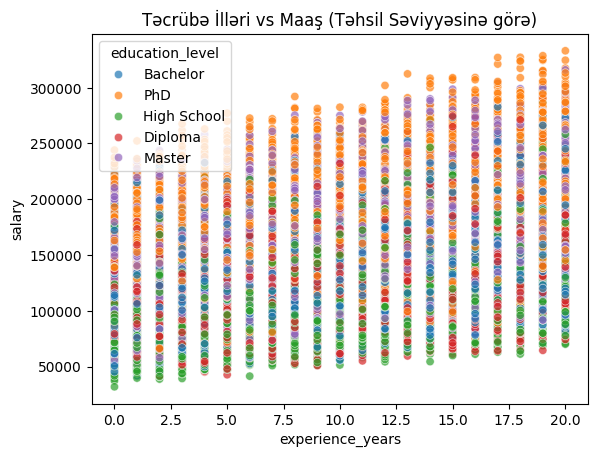

In [8]:
sns.scatterplot(data=df, x='experience_years', y='salary', hue='education_level', alpha=0.7)
plt.title('Təcrübə İlləri vs Maaş (Təhsil Səviyyəsinə görə)')

plt.show()

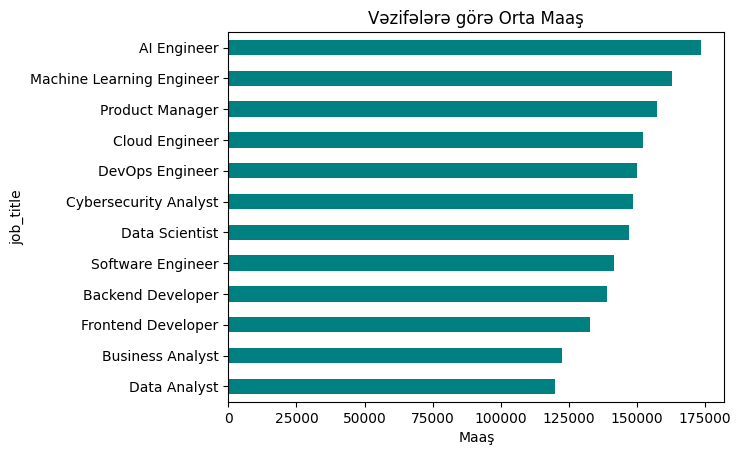

In [9]:
avg_salary_job = df.groupby('job_title')['salary'].mean().sort_values()
avg_salary_job.plot(kind='barh', color='teal')
plt.title('Vəzifələrə görə Orta Maaş')
plt.xlabel('Maaş')

plt.show()

/tmp/ipykernel_6508/3042842096.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='education_level', y='salary', palette='Set2')


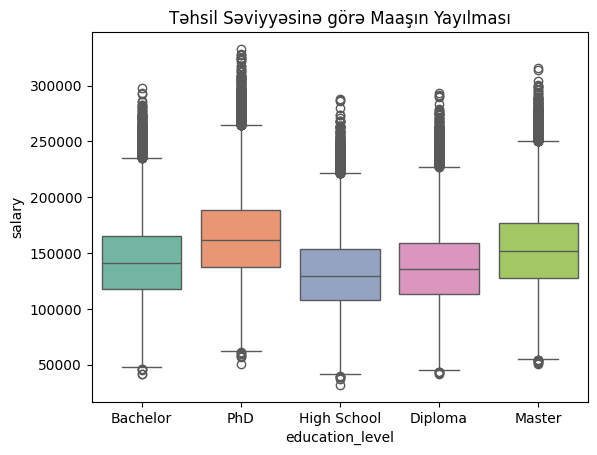

In [10]:
sns.boxplot(data=df, x='education_level', y='salary', palette='Set2')
plt.title('Təhsil Səviyyəsinə görə Maaşın Yayılması')

plt.show()

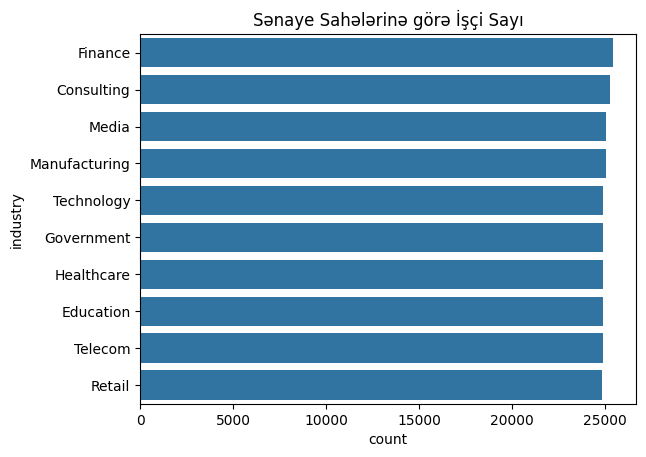

In [11]:
sns.countplot(data=df, y='industry', order=df['industry'].value_counts().index)
plt.title('Sənaye Sahələrinə görə İşçi Sayı')

plt.show()

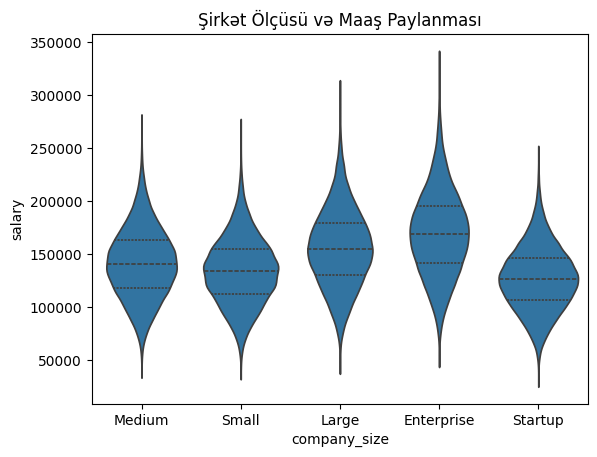

In [12]:
sns.violinplot(data=df, x='company_size', y='salary', inner="quart")
plt.title('Şirkət Ölçüsü və Maaş Paylanması')

plt.show()

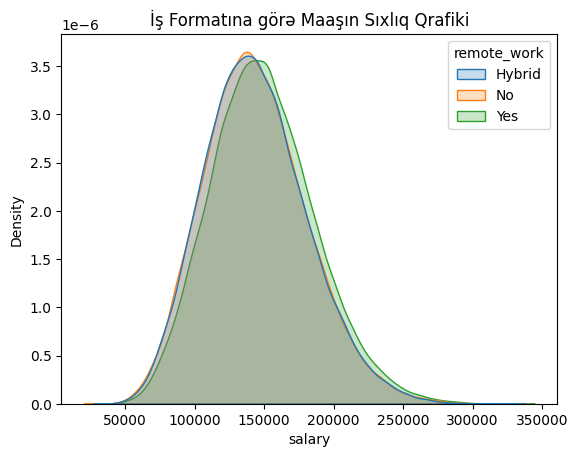

In [13]:
sns.kdeplot(data=df, x='salary', hue='remote_work', fill=True)
plt.title('İş Formatına görə Maaşın Sıxlıq Qrafiki')

plt.show()

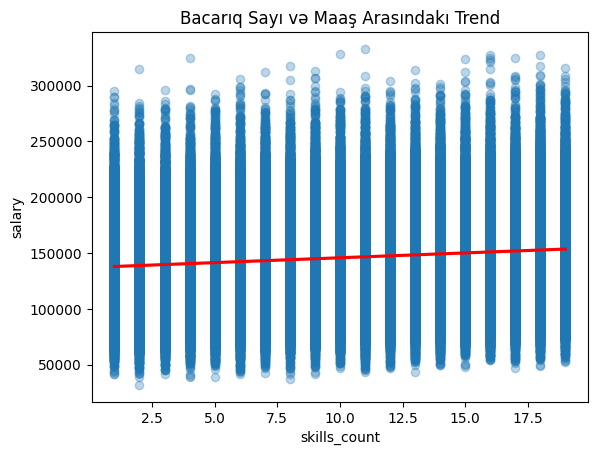

In [14]:
sns.regplot(data=df, x='skills_count', y='salary', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Bacarıq Sayı və Maaş Arasındakı Trend')

plt.show()

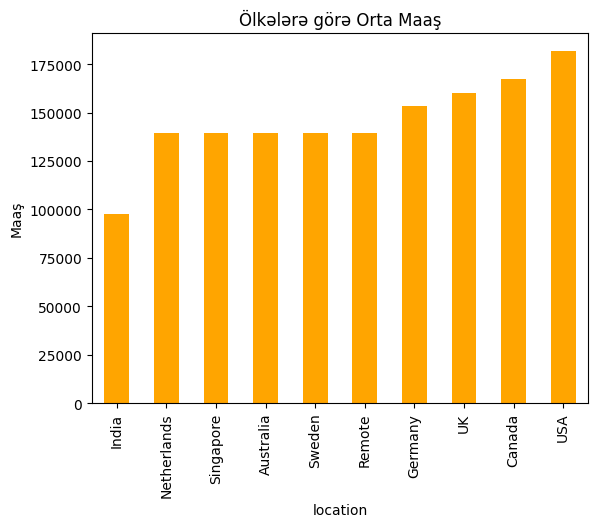

In [15]:
df.groupby('location')['salary'].mean().sort_values().plot(kind='bar', color='orange')
plt.title('Ölkələrə görə Orta Maaş')
plt.ylabel('Maaş')
plt.show()

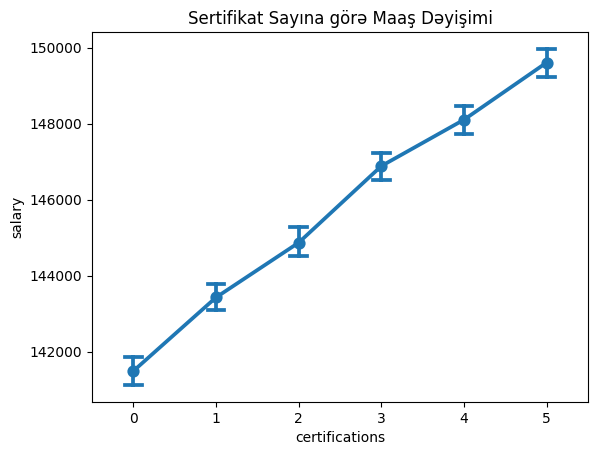

In [16]:
sns.pointplot(data=df, x='certifications', y='salary', capsize=.2)
plt.title('Sertifikat Sayına görə Maaş Dəyişimi')
plt.show()

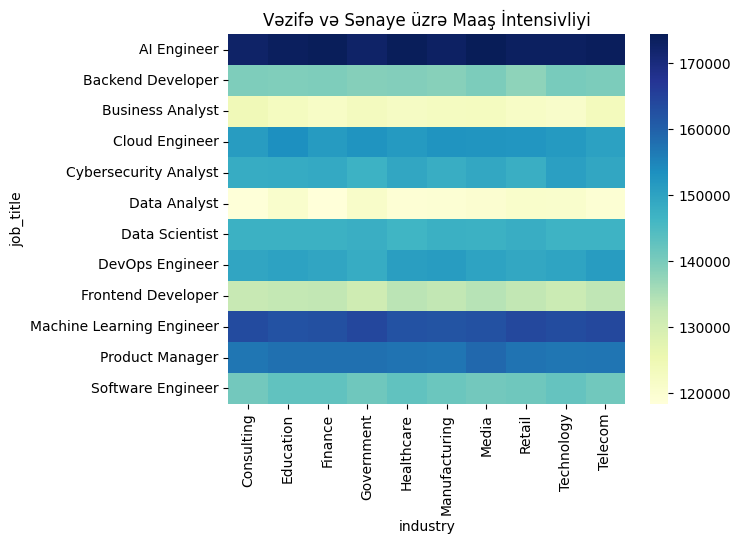

In [17]:
pivot = df.pivot_table(index='job_title', columns='industry', values='salary', aggfunc='mean')
sns.heatmap(pivot, cmap="YlGnBu")
plt.title('Vəzifə və Sənaye üzrə Maaş İntensivliyi')
plt.show()